# 10. Make two-part linear model

1. Make your own example that calls for a two-part linear model:
   - a. Invent plausible story
   - b. Make fake data
   - c. Apply a model

2. Check how the model behaves when in the data:
   - a. The difference between the two parts becomes less pronounced
   - b. Noise increases
   - c. The switch occurs more gradually

In [1]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az
from scipy import stats

np.random.seed(42)

## Students Productivity

A teachers are tracking students productivity during the lectures with a small test-suprises. They measure:
- **X**: Hours since start of classes (0 to 10 hours)
- **Y**: How many inteligent words/calculations they used

The switch occurs around the 5th hour of studying, students are tired, they lack coffeine.

## Make fake data

In [46]:
n_points = 100
X_baseline = np.linspace(0, 10, n_points)

switch_point = 5.0

# increasing productivity
slope1 = 15
intercept1 = 50

# decreasing productivity
slope2 = -10

y_at_switch = intercept1 + slope1 * switch_point
intercept2 = y_at_switch - slope2 * switch_point

Y_baseline = np.zeros(n_points)
for i in range(n_points):
    if X_baseline[i] < switch_point:
        Y_baseline[i] = intercept1 + slope1 * X_baseline[i]
    else:
        Y_baseline[i] = intercept2 + slope2 * X_baseline[i]

# Add some noise
noise_std = 5
Y_baseline += np.random.normal(0, noise_std, n_points)

print(f"Data shape: X={X_baseline.shape}, Y={Y_baseline.shape}")
print(f"Y range: [{Y_baseline.min():.2f}, {Y_baseline.max():.2f}]")

Data shape: X=(100,), Y=(100,)
Y range: [49.09, 137.19]


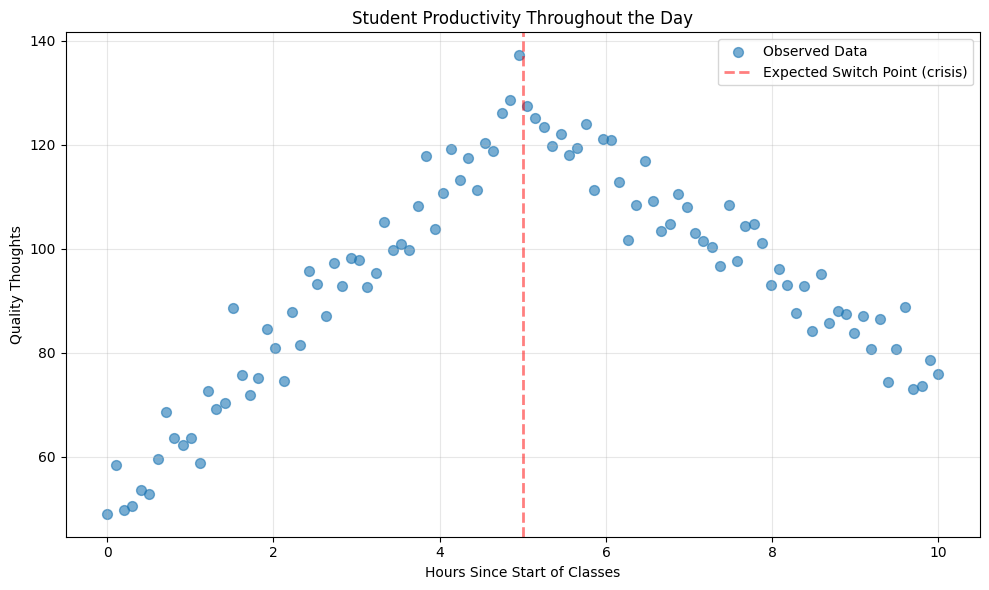

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(X_baseline, Y_baseline, alpha=0.6, s=50, label='Observed Data')
plt.axvline(x=5.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected Switch Point (crisis)')
plt.xlabel('Hours Since Start of Classes')
plt.ylabel('Quality Thoughts')
plt.title('Student Productivity Throughout the Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
def build_and_sample_model(X, Y, model_name="baseline"):

    with pm.Model() as model:
        # Priors
        # Switch point - after 5 hours
        switch_point = pm.Uniform("switch_point", lower=X.min(), upper=X.max())

        slope1 = pm.Normal("slope1", mu=0, sigma=50)
        slope2 = pm.Normal("slope2", mu=0, sigma=50)

        intercept1 = pm.Normal("intercept1", mu=100, sigma=50)
        intercept2 = pm.Normal("intercept2", mu=100, sigma=50)

        # Noise
        sigma = pm.HalfNormal("sigma", sigma=20)

        # if X < switch_point, use first formula, else use second
        mu = pm.math.switch(
            X < switch_point,
            intercept1 + slope1 * X,  # Before switch
            intercept2 + slope2 * X   # After switch
        )

        # Likelihood
        obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=Y)

        print(f"Sampling model: {model_name}")
        idata = pm.sample(1000, tune=1000, chains=2, return_inferencedata=True,
                         random_seed=42, target_accept=0.9, progressbar=True)

    return idata, model

idata_baseline, model_baseline = build_and_sample_model(X_baseline, Y_baseline, "baseline")

Sampling model: baseline


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


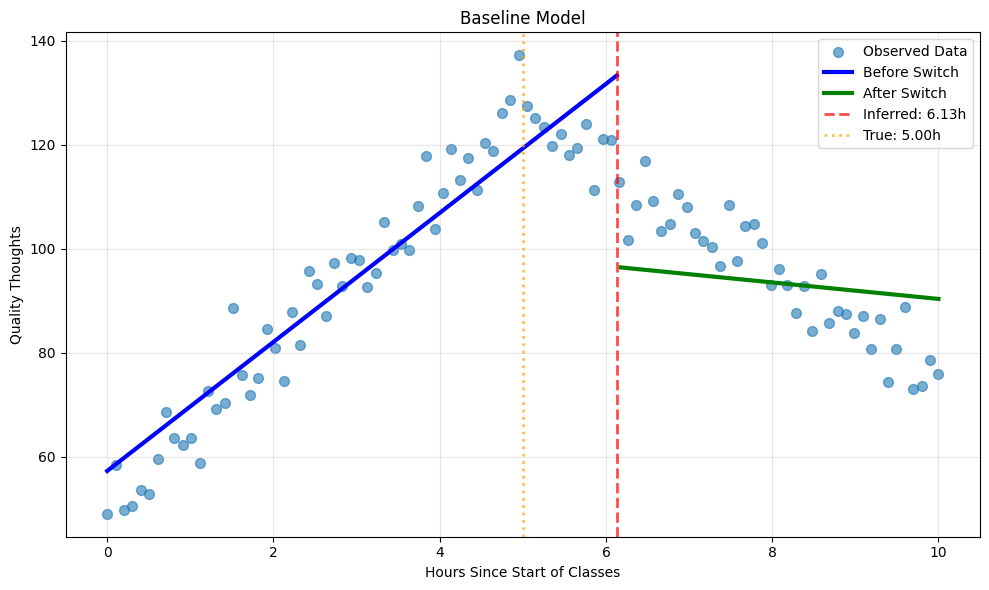


Baseline Model
Switch Point: 6.13 ± 0.06 hours
Slope 1: 12.39, Slope 2: -1.58
Difference: 13.98



In [51]:
def plot_model_results(X, Y, idata, title="Model Results", true_switch=None):

    plt.figure(figsize=(10, 6))

    # Plot data
    plt.scatter(X, Y, alpha=0.6, s=50, label='Observed Data')

    # Get posterior samples
    switch_samples = idata.posterior['switch_point'].values.flatten()
    slope1_samples = idata.posterior['slope1'].values.flatten()
    slope2_samples = idata.posterior['slope2'].values.flatten()
    intercept1_samples = idata.posterior['intercept1'].values.flatten()
    intercept2_samples = idata.posterior['intercept2'].values.flatten()

    # Calculate means
    mean_switch = switch_samples.mean()
    mean_slope1 = slope1_samples.mean()
    mean_slope2 = slope2_samples.mean()
    mean_intercept1 = intercept1_samples.mean()
    mean_intercept2 = intercept2_samples.mean()

    # Plot fitted lines
    X_plot = np.linspace(X.min(), X.max(), 200)

    # Before switch
    mask_before = X_plot < mean_switch
    Y_before = mean_intercept1 + mean_slope1 * X_plot[mask_before]
    plt.plot(X_plot[mask_before], Y_before, 'b-', linewidth=3, label='Before Switch')

    # After switch
    mask_after = X_plot >= mean_switch
    Y_after = mean_intercept2 + mean_slope2 * X_plot[mask_after]
    plt.plot(X_plot[mask_after], Y_after, 'g-', linewidth=3, label='After Switch')

    # Plot switch points
    plt.axvline(x=mean_switch, color='red', linestyle='--', linewidth=2,
               alpha=0.7, label=f'Inferred: {mean_switch:.2f}h')

    if true_switch is not None:
        plt.axvline(x=true_switch, color='orange', linestyle=':', linewidth=2,
                   alpha=0.7, label=f'True: {true_switch:.2f}h')

    plt.xlabel('Hours Since Start of Classes')
    plt.ylabel('Quality Thoughts')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{title}")
    print(f"Switch Point: {mean_switch:.2f} ± {switch_samples.std():.2f} hours")
    print(f"Slope 1: {mean_slope1:.2f}, Slope 2: {mean_slope2:.2f}")
    print(f"Difference: {abs(mean_slope1 - mean_slope2):.2f}\n")

plot_model_results(X_baseline, Y_baseline, idata_baseline,
                  title="Baseline Model", true_switch=5.0)

## 2a. Less Pronounced Difference Between Parts


In [9]:
X_less_diff = np.linspace(0, 10, 100)

slope1_less = 8
slope2_less = -2
intercept1_less = 75

y_switch_less = intercept1_less + slope1_less * 5.0
intercept2_less = y_switch_less - slope2_less * 5.0

Y_less_diff = np.zeros(100)
for i in range(100):
    if X_less_diff[i] < 5.0:
        Y_less_diff[i] = intercept1_less + slope1_less * X_less_diff[i]
    else:
        Y_less_diff[i] = intercept2_less + slope2_less * X_less_diff[i]

# Add noise
Y_less_diff += np.random.normal(0, noise_std, n_points)



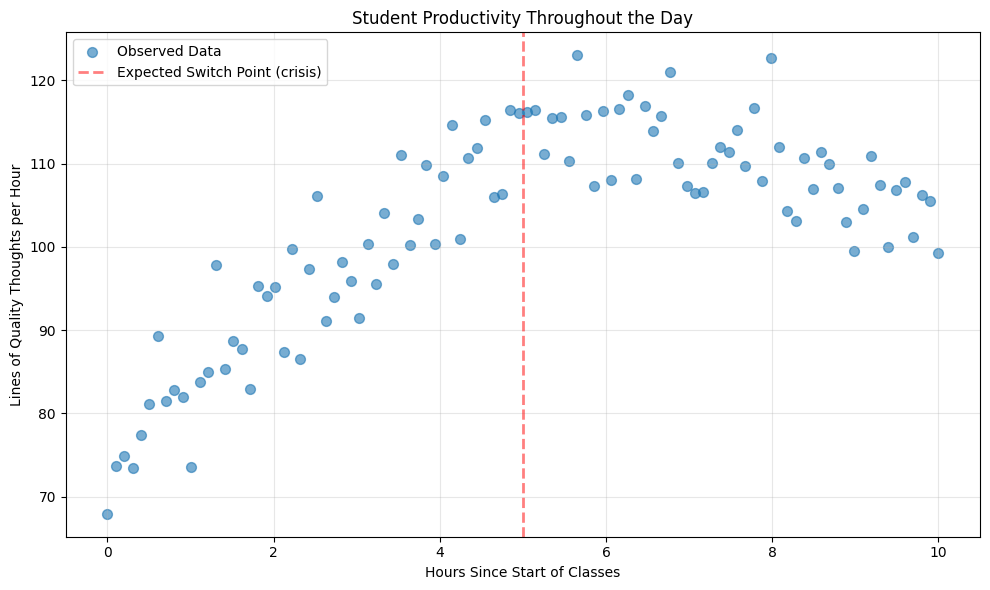

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X_less_diff, Y_less_diff, alpha=0.6, s=50, label='Observed Data')
plt.axvline(x=5.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected Switch Point (crisis)')
plt.xlabel('Hours Since Start of Classes')
plt.ylabel('Quality Thoughts')
plt.title('Student Productivity Throughout the Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Sampling model: less_pronounced


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


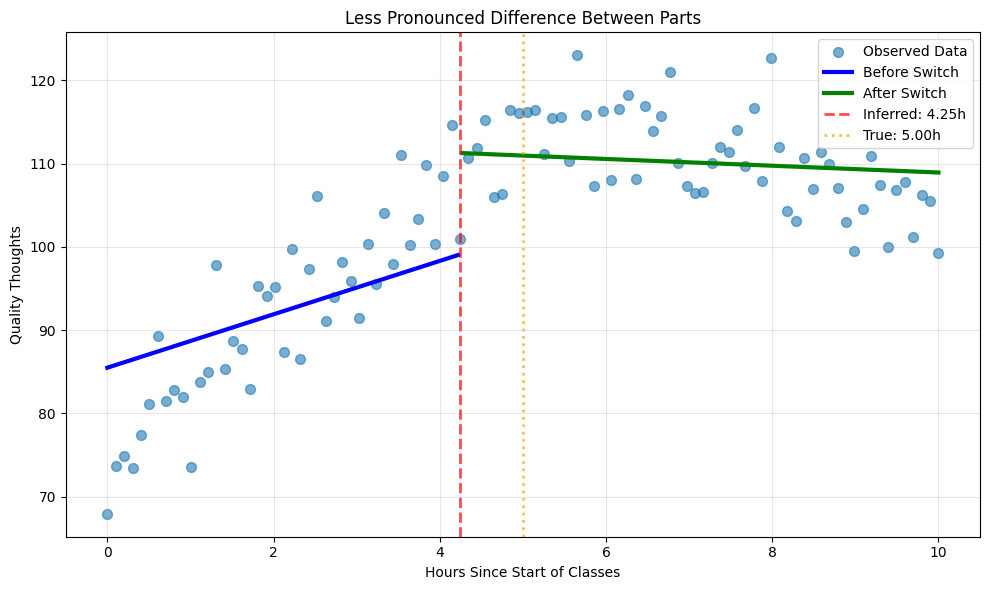


Less Pronounced Difference Between Parts
Switch Point: 4.25 ± 1.09 hours
Slope 1: 3.21, Slope 2: -0.41
Difference: 3.61



In [11]:
idata_less_diff, model_less_diff = build_and_sample_model(
    X_less_diff, Y_less_diff, "less_pronounced"
)

plot_model_results(X_less_diff, Y_less_diff, idata_less_diff,
                  title="Less Pronounced Difference Between Parts", true_switch=5.0)

## 2b. Increased Noise

In [12]:
X_high_noise = np.linspace(0, 10, 100)

slope1_noise = 15
slope2_noise = -10
intercept1_noise = 50

y_switch_noise = intercept1_noise + slope1_noise * 5.0
intercept2_noise = y_switch_noise - slope2_noise * 5.0

Y_high_noise = np.zeros(100)
for i in range(100):
    if X_high_noise[i] < 5.0:
        Y_high_noise[i] = intercept1_noise + slope1_noise * X_high_noise[i]
    else:
        Y_high_noise[i] = intercept2_noise + slope2_noise * X_high_noise[i]

noise_std_high = 15  # 3x larger than baseline
Y_high_noise += np.random.normal(0, noise_std_high, 100)

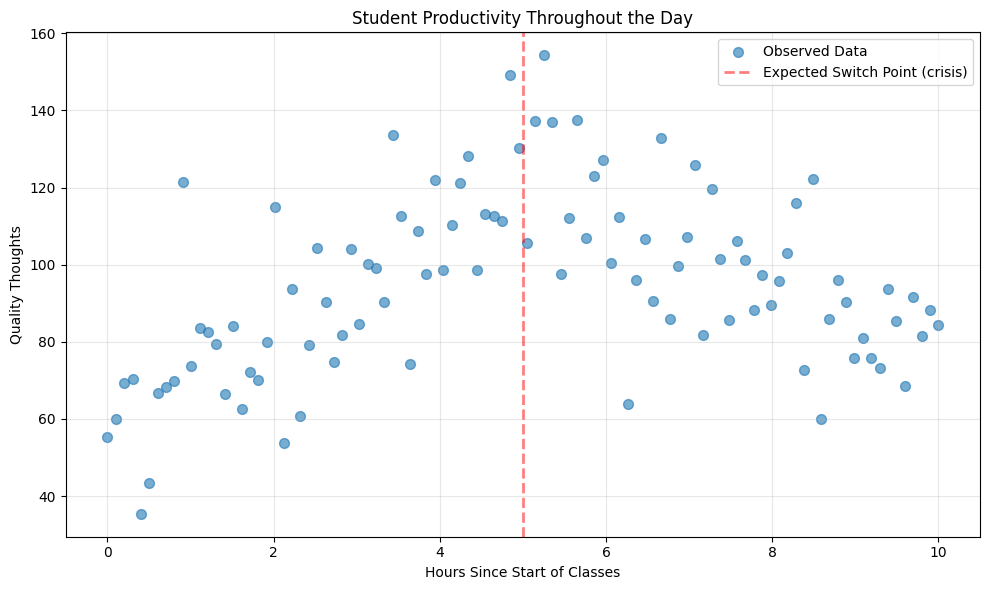

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(X_high_noise, Y_high_noise, alpha=0.6, s=50, label='Observed Data')
plt.axvline(x=5.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected Switch Point (crisis)')
plt.xlabel('Hours Since Start of Classes')
plt.ylabel('Quality Thoughts')
plt.title('Student Productivity Throughout the Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Sampling model: high_noise


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


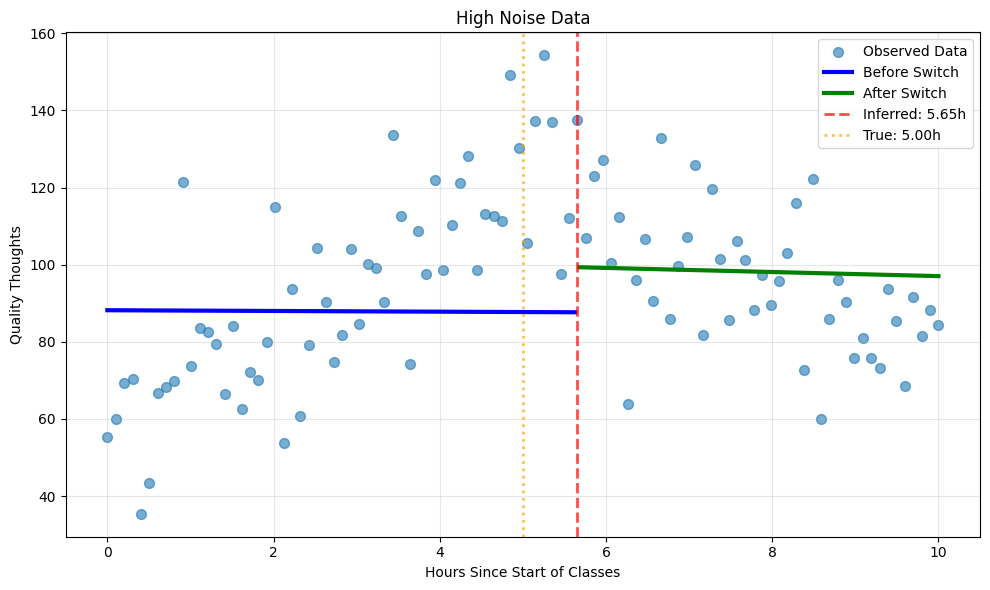


High Noise Data
Switch Point: 5.65 ± 2.67 hours
Slope 1: -0.09, Slope 2: -0.53
Difference: 0.44



In [14]:
idata_high_noise, model_high_noise = build_and_sample_model(
    X_high_noise, Y_high_noise, "high_noise"
)

plot_model_results(X_high_noise, Y_high_noise, idata_high_noise,
                  title="High Noise Data", true_switch=5.0)

## 2c. Gradual Switch

In [40]:
X_gradual = np.linspace(0, 10, 100)

slope1_grad = 15      # Before transition
slope2_grad = 2       # During transition (between 15 and -10)
slope3_grad = -10     # After transition
intercept1_grad = 50

y_at_4 = intercept1_grad + slope1_grad * 4.0
intercept2_grad = y_at_4 - slope2_grad * 4.0

y_at_6 = intercept2_grad + slope2_grad * 6.0
intercept3_grad = y_at_6 - slope3_grad * 6.0

Y_gradual = np.zeros(100)
for i in range(100):
    x = X_gradual[i]

    if x < 4.0:
        # Before transition
        Y_gradual[i] = intercept1_grad + slope1_grad * x
    elif x < 6.0:
        # During transition
        Y_gradual[i] = intercept2_grad + slope2_grad * x
    else:
        # After transition
        Y_gradual[i] = intercept3_grad + slope3_grad * x

# Add noise
Y_gradual += np.random.normal(0, noise_std, n_points)

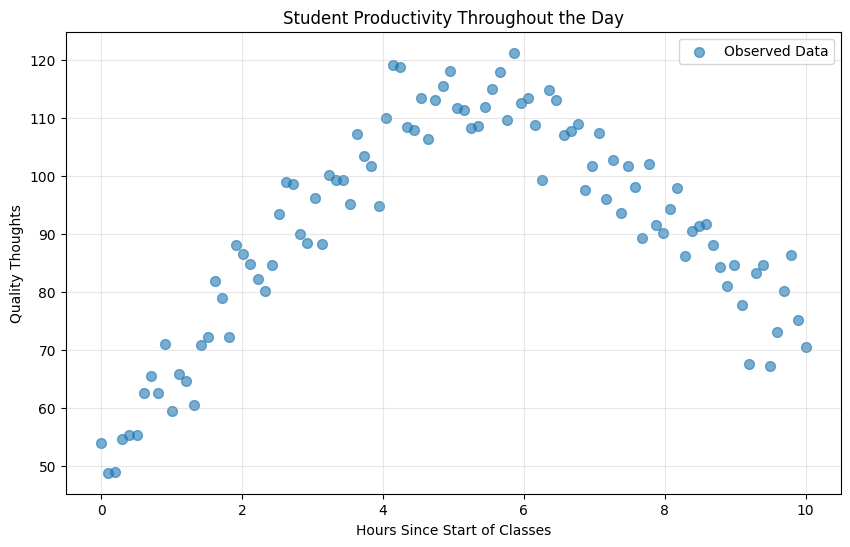

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(X_gradual, Y_gradual, alpha=0.6, s=50, label='Observed Data')
plt.xlabel('Hours Since Start of Classes')
plt.ylabel('Quality Thoughts')
plt.title('Student Productivity Throughout the Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Sampling model: gradual_switch


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


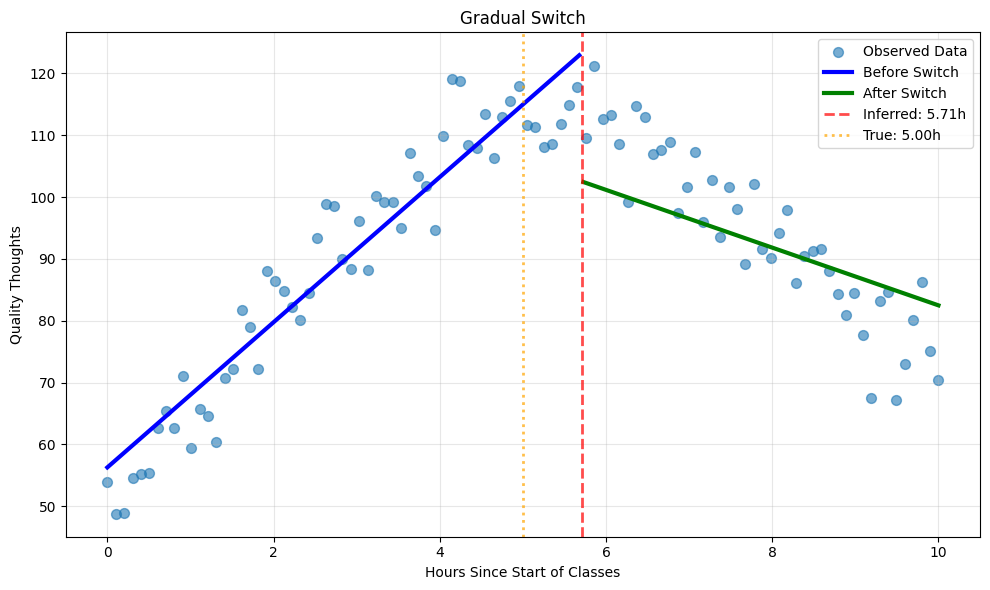


Gradual Switch
Switch Point: 5.71 ± 0.79 hours
Slope 1: 11.74, Slope 2: -4.67
Difference: 16.41



In [42]:
idata_gradual, model_gradual = build_and_sample_model(
    X_gradual, Y_gradual, "gradual_switch"
)

plot_model_results(X_gradual, Y_gradual, idata_gradual,
                  title="Gradual Switch", true_switch=5.0)

The model surprisingly struggled most with the sharp baseline transition, possibly because it's being cautious about overfitting. When slopes are similar, the switch point is harder to detect (as expected). Adding noise helps a bit, maybe just coincidence. The gradual switch (three slopes) performs poorly because the model searches for one sharp switch but the data has a smooth transition zone.